# **1. Perkenalan Dataset**

Eksperimen ini diarahkan ke **Demand Forecasting per Category**, 
Contoh target yang lebih relevan: demand per category, demand per state, atau demand per SKU.


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   (https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)

2. **Isi Dataset**: 

   This dataset provides an in-depth look at the profitability of e-commerce sales. It contains data on a variety of sales channels, including Shiprocket and INCREFF, as well as financial information on related expenses and profits. The columns contain data such as SKU codes, design numbers, stock levels, product categories, sizes and colors. In addition to this we have included the MRPs across multiple stores like Ajio MRP , Amazon MRP , Amazon FBA MRP , Flipkart MRP , Limeroad MRP Myntra MRP and PaytmMRP along with other key parameters like amount paid by customer for the purchase , rate per piece for every individual transaction Also we have added transactional parameters like Date of sale months category fulfilledby B2b Status Qty Currency Gross amt . This is a must-have dataset for anyone trying to uncover the profitability of e-commerce sales in today's marketplace


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [16]:
# ==============================================================================
# Import Library
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
# ==============================================================================
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

In [17]:
# =============================================================================
# Load Dataset
# =============================================================================
dataset_path = r'../amazon_sales_raw/amazon_sale_raw.csv'
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset loaded successfully!
Shape: (128975, 24)

First 5 rows:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount  

In [18]:
# ==============================================================================
# Check data quality
# ==============================================================================

print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"\nMissing Values Count:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected!")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:")
print(df.describe())

DATA QUALITY ASSESSMENT

Dataset Shape: (128975, 24)

Missing Values Count:
Courier Status       6872
currency             7795
Amount               7795
ship-city              33
ship-state             33
ship-postal-code       33
ship-country           33
promotion-ids       49153
fulfilled-by        89698
Unnamed: 22         49050
dtype: int64

Duplicate Rows: 0

Data Types:
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids      

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

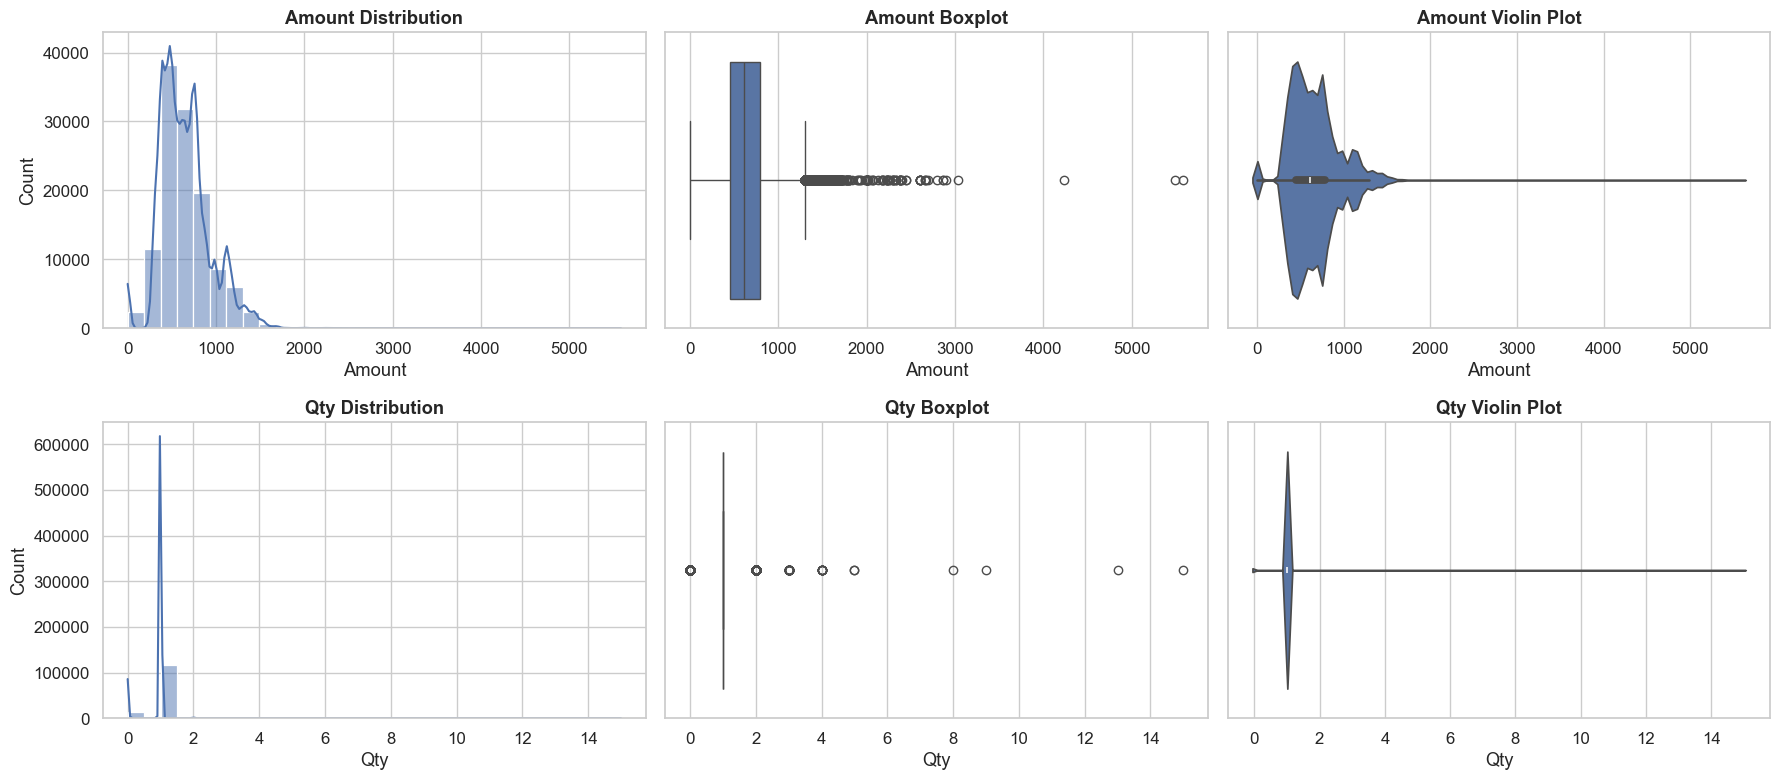

In [20]:
# =============================================================================
# BETTER NUMERIC EDA
# =============================================================================

numeric_cols = ['Amount', 'Qty']

fig, axes = plt.subplots(
    len(numeric_cols),
    3,
    figsize=(18, 8)
)

for idx, col in enumerate(numeric_cols):

    # ---------------------------------------------------
    # HISTOGRAM
    # ---------------------------------------------------
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        ax=axes[idx, 0]
    )

    axes[idx, 0].set_title(
        f'{col} Distribution',
        fontweight='bold'
    )

    # ---------------------------------------------------
    # BOXPLOT
    # ---------------------------------------------------
    sns.boxplot(
        x=df[col],
        ax=axes[idx, 1]
    )

    axes[idx, 1].set_title(
        f'{col} Boxplot',
        fontweight='bold'
    )

    # ---------------------------------------------------
    # VIOLINPLOT
    # ---------------------------------------------------
    sns.violinplot(
        x=df[col],
        ax=axes[idx, 2]
    )

    axes[idx, 2].set_title(
        f'{col} Violin Plot',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Penjelasan Grafik EDA (Amount dan Qty)

Berdasarkan tiga visualisasi (**histogram**, **boxplot**, dan **violin plot**) untuk fitur `Amount` dan `Qty`, dapat disimpulkan:

1. **Distribusi `Amount`**
    - Histogram menunjukkan sebagian besar transaksi berada pada nilai menengah, dengan ekor ke kanan (right-skewed).
    - Boxplot menampilkan banyak titik di atas batas atas, yang menandakan adanya **outlier** pada transaksi bernilai tinggi.
    - Violin plot memperlihatkan kepadatan terbesar di rentang nilai umum, sementara transaksi ekstrem jumlahnya lebih sedikit.

2. **Distribusi `Qty`**
    - Nilai `Qty` terkonsentrasi pada jumlah kecil (dominan di sekitar 1), sehingga distribusinya tidak merata.
    - Boxplot menunjukkan beberapa transaksi dengan kuantitas jauh lebih tinggi dari mayoritas, yang dapat dianggap outlier.
    - Violin plot menegaskan bahwa pembelian multi-item dalam jumlah besar relatif jarang.

3. **Interpretasi Awal**
    - Pola data menunjukkan mayoritas transaksi bersifat normal dengan nilai pembelian standar.
    - Outlier pada `Amount` dan `Qty` kemungkinan berasal dari pembelian besar (misalnya B2B, promo, atau bulk order).
    - Untuk pemodelan lanjutan, data dapat dipertimbangkan menggunakan:
      - **log transform** pada `Amount`,
      - analisis outlier (tetap dipertahankan jika valid secara bisnis).

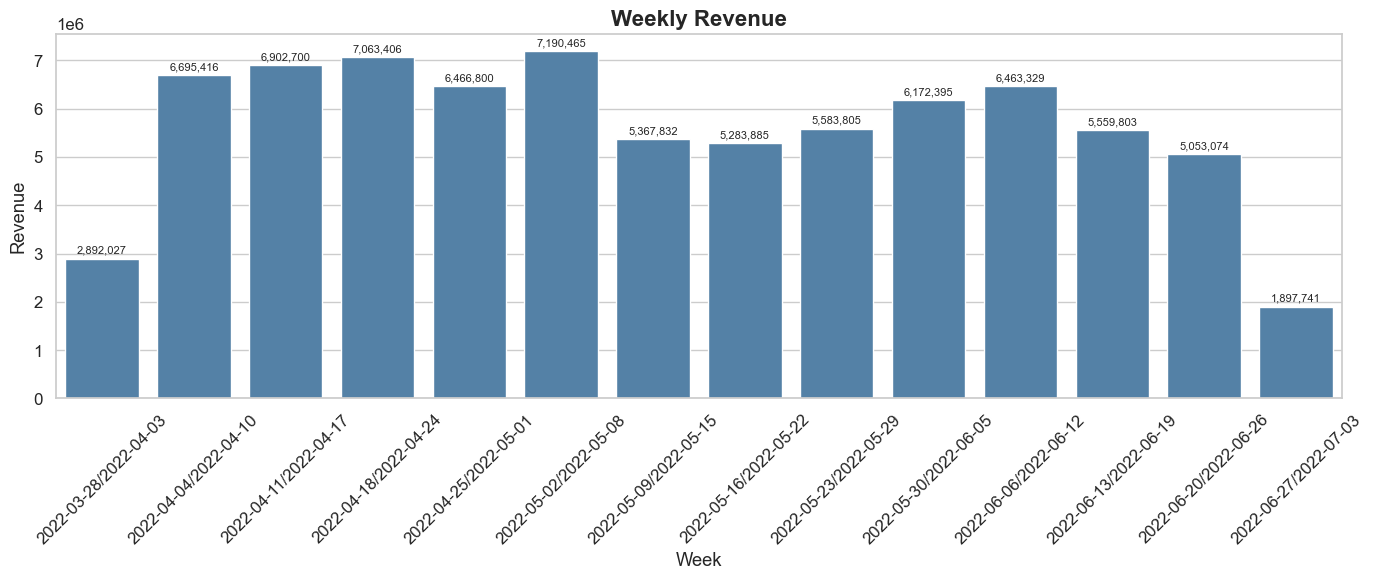

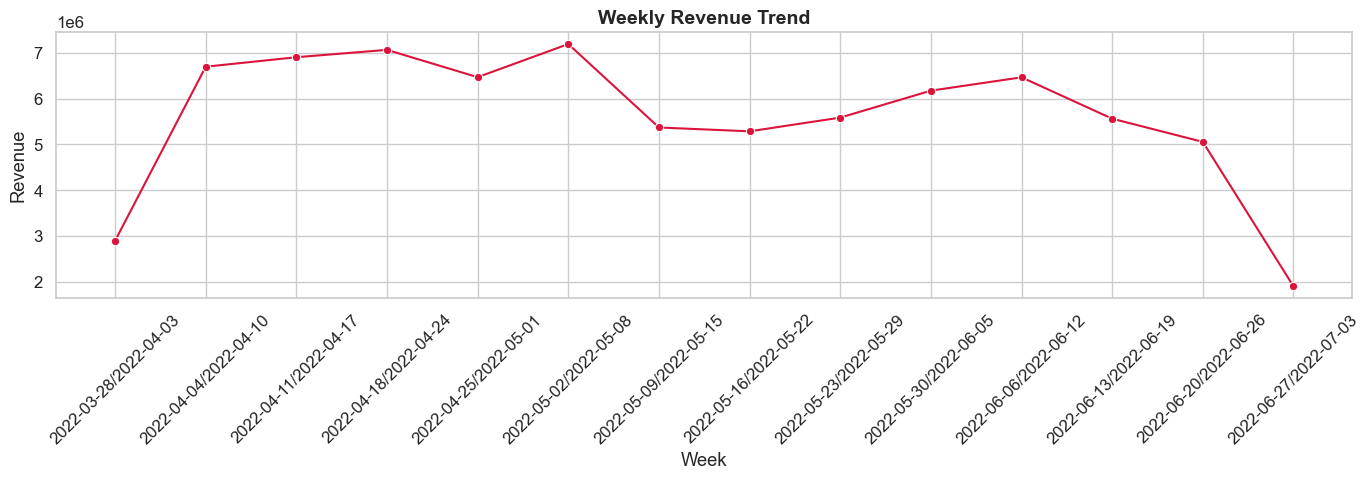

Rekapitulasi Total Revenue per Minggu:
                 Week     Amount
2022-03-28/2022-04-03 2892027.36
2022-04-04/2022-04-10 6695415.95
2022-04-11/2022-04-17 6902700.42
2022-04-18/2022-04-24 7063406.00
2022-04-25/2022-05-01 6466799.96
2022-05-02/2022-05-08 7190464.94
2022-05-09/2022-05-15 5367831.55
2022-05-16/2022-05-22 5283885.33
2022-05-23/2022-05-29 5583804.55
2022-05-30/2022-06-05 6172395.21
2022-06-06/2022-06-12 6463328.67
2022-06-13/2022-06-19 5559803.37
2022-06-20/2022-06-26 5053074.03
2022-06-27/2022-07-03 1897740.96


In [21]:
# =============================================================================
# Time Series Analysis (Weekly)
# =============================================================================
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Aggregate by week (week-ending). This reduces stacking from daily points.
weekly_sales = (
    df.set_index('Date')
    .resample('W')['Amount']
    .sum()
    .reset_index()
)
weekly_sales['Week'] = weekly_sales['Date'].dt.to_period('W').astype(str)

# Bar plot per week with annotations
plt.figure(figsize=(14,6))
sns.barplot(data=weekly_sales, x='Week', y='Amount', color='steelblue')
plt.title('Weekly Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Annotate values above bars (small offset)
offset = weekly_sales['Amount'].max() * 0.01 if weekly_sales['Amount'].max() > 0 else 1
for i, v in enumerate(weekly_sales['Amount']):
    plt.text(i, v + offset, f"{v:,.0f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Optional line plot to show trend
plt.figure(figsize=(14,5))
sns.lineplot(data=weekly_sales, x='Week', y='Amount', marker='o', color='crimson')
plt.title('Weekly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tampilkan angka-angka total revenue per minggu (summary tabel)
print("Rekapitulasi Total Revenue per Minggu:")
print(weekly_sales[['Week', 'Amount']].to_string(index=False))

### Analisis Trend Penjualan Mingguan

Berdasarkan grafik dan tabel rekapitulasi revenue mingguan di atas, terlihat beberapa pola penting:

- **Fluktuasi Revenue** 

Pendapatan mingguan mengalami fluktuasi yang cukup signifikan, dengan beberapa minggu menunjukkan lonjakan penjualan yang tinggi.


- **Ada Puncak Penjualan**

Terdapat minggu-minggu tertentu (misal awal Mei dan pertengahan Juni) di mana revenue mencapai puncak, kemungkinan dipengaruhi oleh promo, event khusus, atau musim belanja.


- **Terjadi Penurunan Bertahap**

Setelah periode puncak, revenue cenderung menurun secara bertahap, menandakan adanya siklus atau efek musiman dalam penjualan.


- **Overall Stabilitas**

Meskipun terdapat fluktuasi, secara umum revenue mingguan tetap berada pada kisaran tertentu, menunjukkan kestabilan bisnis secara keseluruhan.

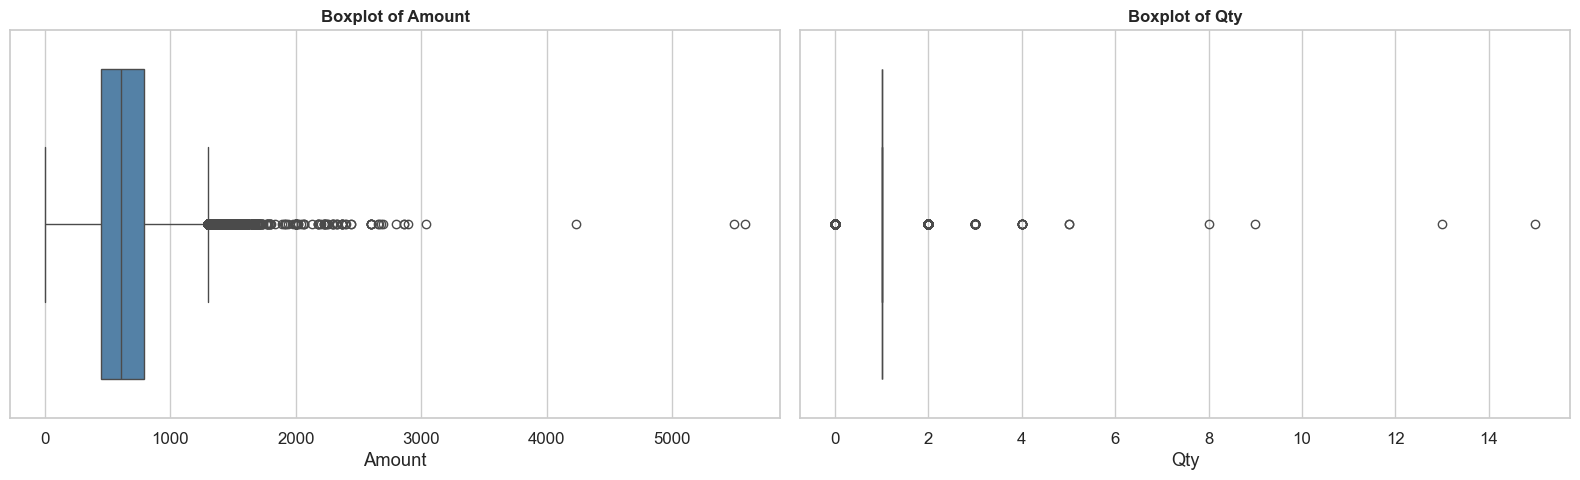

Feature    Q1    Q3   IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
 Amount 449.0 788.0 339.0        -59.5       1296.5           3600   2.791239
    Qty   1.0   1.0   0.0          1.0          1.0          13195  10.230665

Outliers Count (Amount): 3600
Outlier Percentage (Amount): 2.79%
Lower Bound: -59.50
Upper Bound: 1296.50


In [22]:
# =============================================================================
# OUTLIER DETECTION (EARLY CHECK)
# =============================================================================

cols = [col for col in numeric_cols if col in df.columns]

fig, axes = plt.subplots(1, len(cols), figsize=(8 * len(cols), 5))
if len(cols) == 1:
    axes = [axes]

outlier_summary = []

for ax, col in zip(axes, cols):
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_count = mask.sum()
    outlier_pct = outlier_count / len(df) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_pct
    })

    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

outlier_summary = pd.DataFrame(outlier_summary)
print(outlier_summary.to_string(index=False))

# Fokus awal pada outlier di Amount
amount_series = df['Amount'].dropna()
q1 = amount_series.quantile(0.25)
q3 = amount_series.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print(f"\nOutliers Count (Amount): {len(outliers)}")
print(f"Outlier Percentage (Amount): {len(outliers) / len(df) * 100:.2f}%")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

### BoxPlot Outlier

Terdapat 3600 outlier untuk pengecekan selanjutnya apakah normal atau tidak

OUTLIER DETECTION

Q1: 449.00
Q3: 788.00
IQR: 339.00

Lower Bound: -59.50
Upper Bound: 1296.50

Total Outliers: 3600
Outlier Percentage: 2.79%


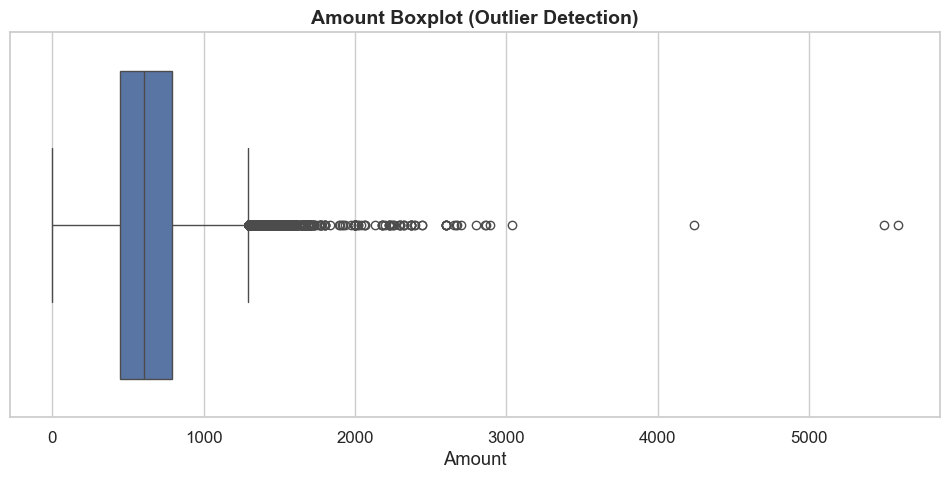


TOP 20 HIGHEST OUTLIERS
             Date             Order ID       Category  Qty   Amount  \
42039  2022-04-05  402-5239558-4281957            Set    8  5584.00   
11160  2022-04-23  403-4106553-1691525            Set    5  5495.00   
24494  2022-04-16  407-3483041-9133135            Set    0  4235.72   
89150  2022-05-02  406-7195963-2374765            Set    4  3036.00   
121225 2022-06-06  404-4712917-7300332            Set    2  2894.00   
28814  2022-04-13  408-9885439-6698733            Set    2  2864.00   
39944  2022-04-06  408-3363121-6123562  Western Dress    4  2860.00   
79899  2022-05-07  405-6877720-7865168          kurta    4  2796.00   
63974  2022-05-19  408-9361250-7029128            Set    2  2698.00   
75760  2022-05-10  402-9141667-1791537            Set    2  2676.00   
121019 2022-06-06  403-0343365-3075550            Set    4  2664.00   
54605  2022-05-27  171-9419863-7830701  Western Dress    3  2655.00   
67764  2022-05-16  402-0603541-4663511            Se

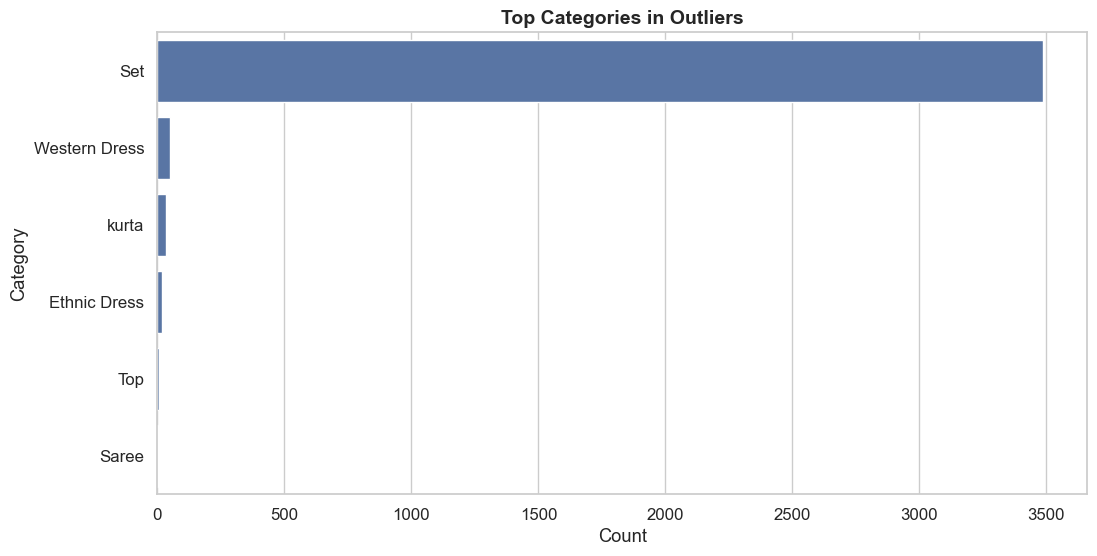


STATUS DISTRIBUTION IN OUTLIERS
Status
Shipped                          2354
Shipped - Delivered to Buyer      872
Cancelled                         228
Shipped - Returned to Seller       65
Shipped - Picked Up                36
Pending                            27
Shipped - Returning to Seller       7
Pending - Waiting for Pick Up       7
Shipped - Out for Delivery          4
Name: count, dtype: int64

QUANTITY DISTRIBUTION IN OUTLIERS
Qty
1    3404
2     119
0      45
3      21
4       8
5       2
8       1
Name: count, dtype: int64

B2B VS NON-B2B OUTLIERS
B2B
False    3563
True       37
Name: count, dtype: int64

TOP STATES WITH OUTLIERS
ship-state
MAHARASHTRA       548
KARNATAKA         441
UTTAR PRADESH     362
TELANGANA         302
TAMIL NADU        229
DELHI             198
HARYANA           166
ANDHRA PRADESH    146
WEST BENGAL       141
KERALA            130
Name: count, dtype: int64


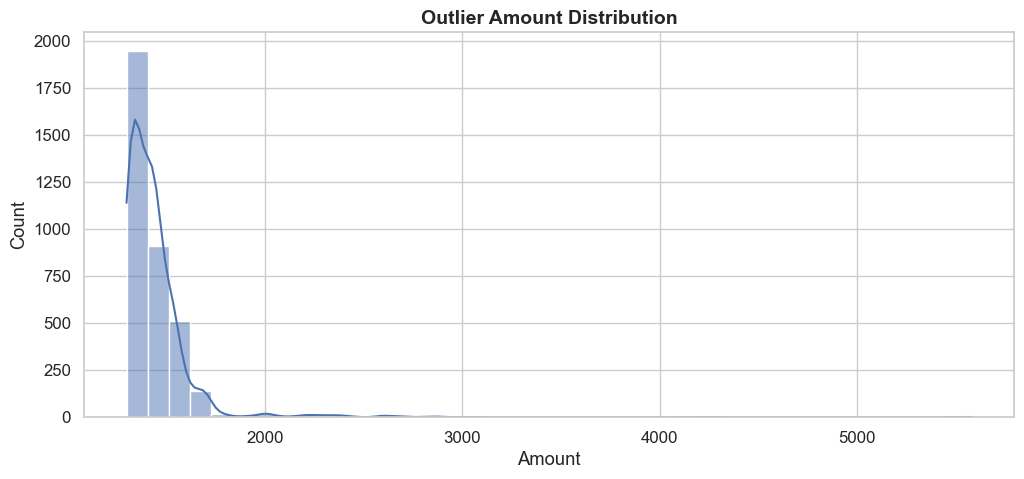

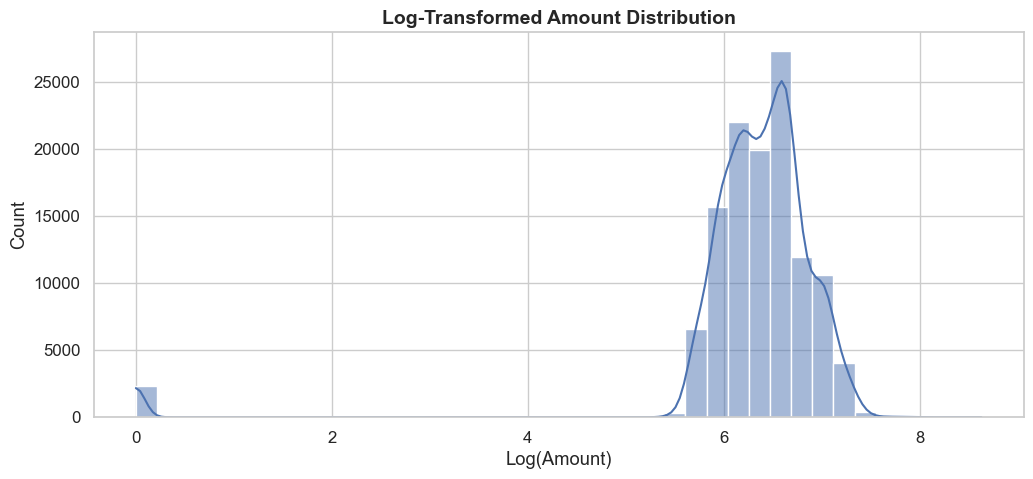


EXTREME OUTLIER CASES
             Date             Order ID       Category  Qty   Amount  \
42039  2022-04-05  402-5239558-4281957            Set    8  5584.00   
11160  2022-04-23  403-4106553-1691525            Set    5  5495.00   
24494  2022-04-16  407-3483041-9133135            Set    0  4235.72   
89150  2022-05-02  406-7195963-2374765            Set    4  3036.00   
121225 2022-06-06  404-4712917-7300332            Set    2  2894.00   
28814  2022-04-13  408-9885439-6698733            Set    2  2864.00   
39944  2022-04-06  408-3363121-6123562  Western Dress    4  2860.00   
79899  2022-05-07  405-6877720-7865168          kurta    4  2796.00   
63974  2022-05-19  408-9361250-7029128            Set    2  2698.00   
75760  2022-05-10  402-9141667-1791537            Set    2  2676.00   
121019 2022-06-06  403-0343365-3075550            Set    4  2664.00   
54605  2022-05-27  171-9419863-7830701  Western Dress    3  2655.00   
67764  2022-05-16  402-0603541-4663511            Set 

In [23]:
# =============================================================================
# OUTLIER ANALYSIS - E-COMMERCE SALES DATA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# IQR OUTLIER DETECTION
# =============================================================================

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)

print(f"\nQ1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

print(f"\nLower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# =============================================================================
# DETECT OUTLIERS
# =============================================================================

outliers = df[
    (df['Amount'] < lower_bound) |
    (df['Amount'] > upper_bound)
]

print(f"\nTotal Outliers: {len(outliers)}")

outlier_percentage = (len(outliers) / len(df)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

# =============================================================================
# VISUALIZE OUTLIERS
# =============================================================================

plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df['Amount']
)

plt.title(
    'Amount Boxplot (Outlier Detection)',
    fontsize=14,
    fontweight='bold'
)

plt.show()

# =============================================================================
# TOP HIGHEST OUTLIERS
# =============================================================================

print("\n" + "=" * 80)
print("TOP 20 HIGHEST OUTLIERS")
print("=" * 80)

top_outliers = outliers.sort_values(
    by='Amount',
    ascending=False
)

cols_to_show = [
    'Date',
    'Order ID',
    'Category',
    'Qty',
    'Amount',
    'Status',
    'ship-state',
    'B2B',
    'Fulfilment'
]

print(top_outliers[cols_to_show].head(20))

# =============================================================================
# OUTLIER STATISTICS
# =============================================================================

print("\n" + "=" * 80)
print("OUTLIER STATISTICS")
print("=" * 80)

print(outliers['Amount'].describe())

# =============================================================================
# CHECK CATEGORY DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("TOP CATEGORIES IN OUTLIERS")
print("=" * 80)

category_counts = (
    outliers['Category']
    .value_counts()
    .head(10)
)

print(category_counts)

# =============================================================================
# CATEGORY REVENUE PLOT
# =============================================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title(
    'Top Categories in Outliers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Count')

plt.show()

# =============================================================================
# CHECK STATUS DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("STATUS DISTRIBUTION IN OUTLIERS")
print("=" * 80)

print(outliers['Status'].value_counts())

# =============================================================================
# CHECK QTY DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("QUANTITY DISTRIBUTION IN OUTLIERS")
print("=" * 80)

print(outliers['Qty'].value_counts().head(10))

# =============================================================================
# CHECK B2B DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("B2B VS NON-B2B OUTLIERS")
print("=" * 80)

print(outliers['B2B'].value_counts())

# =============================================================================
# STATE ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("TOP STATES WITH OUTLIERS")
print("=" * 80)

state_counts = (
    outliers['ship-state']
    .value_counts()
    .head(10)
)

print(state_counts)

# =============================================================================
# VISUALIZE OUTLIER DISTRIBUTION
# =============================================================================

plt.figure(figsize=(12, 5))

sns.histplot(
    outliers['Amount'],
    bins=40,
    kde=True
)

plt.title(
    'Outlier Amount Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Amount')

plt.show()

# =============================================================================
# LOG TRANSFORM VISUALIZATION
# =============================================================================

df['log_amount'] = np.log1p(df['Amount'])

plt.figure(figsize=(12, 5))

sns.histplot(
    df['log_amount'],
    bins=40,
    kde=True
)

plt.title(
    'Log-Transformed Amount Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Log(Amount)')

plt.show()

# =============================================================================
# CHECK EXTREME CASES
# =============================================================================

print("\n" + "=" * 80)
print("EXTREME OUTLIER CASES")
print("=" * 80)

extreme_outliers = outliers[
    outliers['Amount'] > outliers['Amount'].quantile(0.99)
]

print(
    extreme_outliers[
        cols_to_show
    ].sort_values(
        by='Amount',
        ascending=False
    ).head(20)
)


### Temuan Analisis Outlier


### Ringkasan Temuan Outlier

Analisis outlier dilakukan pada fitur `Amount` menggunakan metode Interquartile Range (IQR) untuk mengidentifikasi nilai transaksi yang sangat tinggi pada dataset e-commerce.

---

### Mengapa outlier (transaksi bernilai tinggi) terjadi

Berdasarkan analisis data dan inspeksi baris outlier, penyebab utama outlier adalah:

- Pembelian jumlah besar / bulk (Qty > 1, beberapa sampai 8) — transaksi B2B atau pembelian grosir menaikkan `Amount`.  
- Produk bundling / "Set" dan kategori premium (mis. Set, Western Dress) — item dengan MRP/price per set lebih tinggi.  
- Promo atau fasilitas pembiayaan (promotion-ids seperti "Amazon PLCC Free-Financing") yang mendorong nilai transaksi lebih besar.  
- Kasus pengembalian atau status khusus (Cancelled / Returned / Unshipped) tercatat sebelum/selesai sehingga nilai tercatat tampak ekstrem.  
- Periode event/promo musiman (flash sale, kampanye) — lonjakan sementara pada minggu tertentu.  
- Kesalahan data atau entri (duplikasi, kesalahan mata uang, format jumlah, kolom kosong) yang dapat menghasilkan nilai tidak valid.  
- Kombinasi fitur (qty × harga per unit) dan logika fulfillment (merchant vs fulfillment) menyebabkan variasi ekstrem.

### Metode Deteksi Outlier

Metode IQR diterapkan dengan rumus berikut:

- Q1 (persentil ke-25): 449.00
- Q3 (persentil ke-75): 788.00
- IQR: 339.00

Batas outlier:

- Batas Bawah: -59.50
- Batas Atas: 1296.50

Transaksi dengan `Amount > 1296.50` diklasifikasikan sebagai outlier.

---

### Ringkasan Outlier

| Metrik            | Nilai    |
|-------------------|----------|
| Total Outlier     | 3.600    |
| Ukuran Dataset    | 128.975  |
| Persentase Outlier| 2,79%    |
| Amount Maksimum   | 5.584,00 |

Persentase outlier relatif kecil dan masih dalam kisaran realistis untuk data transaksi e-commerce.

---

### Temuan Utama

#### 1. Sebagian Besar Outlier Berasal dari Kategori "Set"

Distribusi kategori outlier menunjukkan mayoritas transaksi bernilai tinggi berasal dari kategori `Set`.

| Kategori        | Jumlah |
|-----------------|--------|
| Set             | 3487   |
| Western Dress   | 50     |
| kurta           | 34     |
| Ethnic Dress    | 19     |

#### Interpretasi

Hal ini menunjukkan bahwa outlier terutama terkait dengan produk fashion premium atau bundling, bukan anomali acak atau data yang rusak.

---

#### 2. Sebagian Besar Outlier Memiliki Quantity = 1

Distribusi quantity pada outlier:

| Qty | Jumlah    |
|-----|-----------|
| 1   | 3404      |
| 2   | 119       |
| 3+  | Sangat Sedikit |

#### Interpretasi

Nilai transaksi yang sangat tinggi bukan disebabkan oleh pembelian dalam jumlah besar, melainkan karena produk premium dengan harga tinggi.

---

#### 3. Sebagian Besar Outlier Merupakan Transaksi Selesai yang Valid

Distribusi status:

| Status                        | Jumlah |
|-------------------------------|--------|
| Shipped                       | 2354   |
| Shipped - Delivered to Buyer  | 872    |
| Cancelled                     | 228    |

#### Interpretasi

Sebagian besar transaksi outlier merupakan pesanan yang sah dan telah selesai, sehingga nilai tinggi tersebut adalah kejadian bisnis yang nyata, bukan kesalahan input data.

---

#### 4. Outlier Tidak Didominasi oleh Transaksi B2B

| Status B2B | Jumlah |
|------------|--------|
| False      | 3563   |
| True       | 37     |

#### Interpretasi

Mayoritas transaksi bernilai tinggi berasal dari pembelian konsumen biasa, bukan pesanan perusahaan atau grosir.

---

#### 5. Distribusi Geografis

Provinsi dengan transaksi outlier terbanyak:

| Provinsi         | Jumlah |
|------------------|--------|
| Maharashtra      | 548    |
| Karnataka        | 441    |
| Uttar Pradesh    | 362    |
| Telangana        | 302    |

#### Interpretasi

Outlier tersebar di berbagai provinsi besar, menandakan permintaan pelanggan yang luas, bukan anomali yang terisolasi.

---

### Kasus Outlier Tidak Valid yang Ditemukan

Beberapa transaksi diidentifikasi tidak valid untuk keperluan peramalan, seperti:

- Pesanan dibatalkan
- Quantity = 0
- Transaksi pending

Contoh:

| Qty | Status     | Amount  |
|-----|-----------|---------|
| 0   | Cancelled | 4235.72 |

Catatan: Data ini harus dikeluarkan dari dataset peramalan karena tidak merepresentasikan pendapatan yang terealisasi.

---

### Keputusan Akhir terhadap Outlier

Analisis menunjukkan sebagian besar outlier adalah transaksi produk premium yang sah, bukan data yang rusak atau abnormal.

Oleh karena itu:

- Outlier valid (shipped/delivered) akan dipertahankan.
- Transaksi tidak valid (cancelled, pending, Qty = 0) akan dihapus.
- Transformasi log akan diterapkan saat pemodelan untuk mengurangi skewness dan menstabilkan variansi.

---

### Insight Bisnis

Adanya transaksi premium bernilai tinggi menunjukkan:

- Permintaan produk premium yang kuat
- Perilaku harga premium pada kategori "Set"
- Lonjakan pendapatan yang realistis dan penting untuk model peramalan

Menghapus seluruh observasi ini dapat berdampak negatif pada kemampuan model dalam mempelajari pola penjualan dan volatilitas pendapatan yang realistis.

COMPARATIVE ANALYSIS: OUTLIERS vs NORMAL DATA
Column 'anomaly_flag' not found — marking all rows as normal.

       Metric   Normal Data  Anomaly Data
        Count 128975.000000           0.0
  Mean Amount    648.561465           NaN
Median Amount    605.000000           NaN
   Std Amount    281.211687           NaN
   Min Amount      0.000000           NaN
   Max Amount   5584.000000           NaN


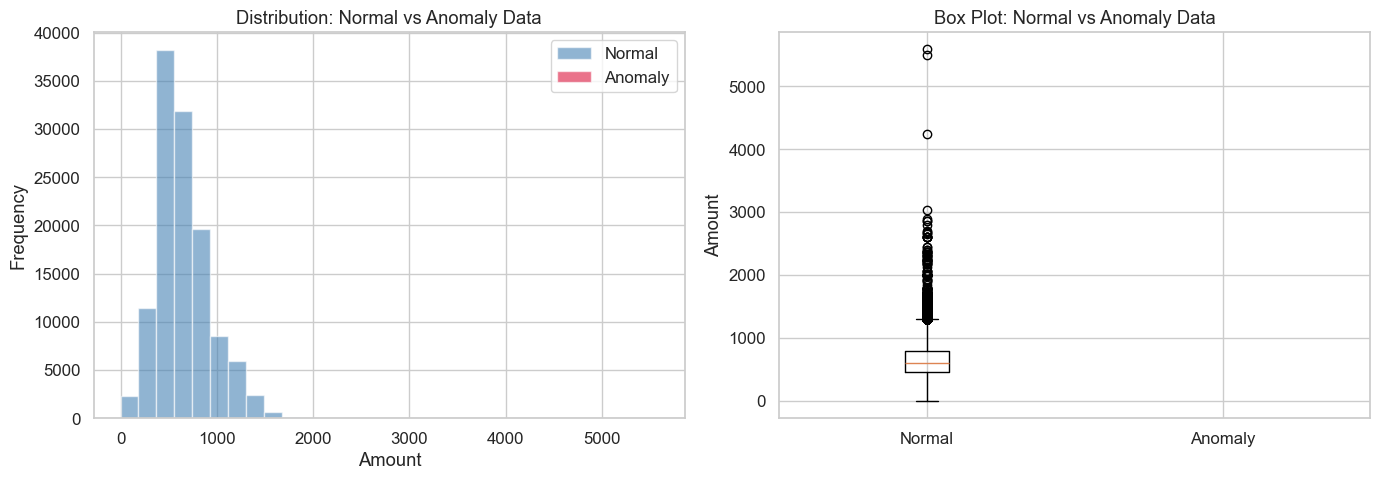


CATEGORY DISTRIBUTION IN ANOMALIES
Series([], Name: count, dtype: int64)

B2B vs NON-B2B IN ANOMALIES
Series([], Name: count, dtype: int64)


In [24]:
# =============================================================================
# SUMMARY STATISTICS - OUTLIER vs NORMAL DATA
# =============================================================================

print("=" * 80)
print("COMPARATIVE ANALYSIS: OUTLIERS vs NORMAL DATA")
print("=" * 80)

# Separate normal and outlier data
if 'anomaly_flag' not in df.columns:
    print("Column 'anomaly_flag' not found — marking all rows as normal.")
    df['anomaly_flag'] = 0
else:
    df['anomaly_flag'] = pd.to_numeric(df['anomaly_flag'], errors='coerce').fillna(0).astype(int)

normal_data = df[df['anomaly_flag'] == 0]
anomaly_data_filtered = df[df['anomaly_flag'] == 1]

# Compare statistics
comparison_stats = pd.DataFrame({
    'Metric': ['Count', 'Mean Amount', 'Median Amount', 'Std Amount', 'Min Amount', 'Max Amount'],
    'Normal Data': [
        len(normal_data),
        normal_data['Amount'].mean(),
        normal_data['Amount'].median(),
        normal_data['Amount'].std(),
        normal_data['Amount'].min(),
        normal_data['Amount'].max()
    ],
    'Anomaly Data': [
        len(anomaly_data_filtered),
        anomaly_data_filtered['Amount'].mean(),
        anomaly_data_filtered['Amount'].median(),
        anomaly_data_filtered['Amount'].std(),
        anomaly_data_filtered['Amount'].min(),
        anomaly_data_filtered['Amount'].max()
    ]
})

print("\n" + comparison_stats.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
axes[0].hist(normal_data['Amount'].dropna(), bins=30, alpha=0.6, label='Normal', color='steelblue')
axes[0].hist(anomaly_data_filtered['Amount'].dropna(), bins=30, alpha=0.6, label='Anomaly', color='crimson')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution: Normal vs Anomaly Data')
axes[0].legend()

# Box plot comparison
box_data = [normal_data['Amount'].dropna(), anomaly_data_filtered['Amount'].dropna()]
axes[1].boxplot(box_data, labels=['Normal', 'Anomaly'])
axes[1].set_ylabel('Amount')
axes[1].set_title('Box Plot: Normal vs Anomaly Data')

plt.tight_layout()
plt.show()

# Category distribution in anomalies
print("\n" + "=" * 80)
print("CATEGORY DISTRIBUTION IN ANOMALIES")
print("=" * 80)
print(anomaly_data_filtered['Category'].value_counts())

# B2B analysis in anomalies
print("\n" + "=" * 80)
print("B2B vs NON-B2B IN ANOMALIES")
print("=" * 80)
print(anomaly_data_filtered['B2B'].value_counts())

#### Analisis Kategori dan Tipe Pelanggan pada Transaksi Anomali

#### Ringkasan

Investigasi tambahan dilakukan untuk memahami karakteristik transaksi anomali yang teridentifikasi selama proses deteksi outlier.

Analisis difokuskan pada:

- Distribusi kategori produk
- Perilaku pelanggan B2B vs non-B2B

Analisis ini membantu menentukan apakah anomali yang terdeteksi merupakan data yang rusak atau pola bisnis yang bermakna.

---

#### Distribusi Kategori pada Transaksi Anomali

| Kategori        | Jumlah |
|-----------------|--------|
| Set             | 367    |
| Western Dress   | 30     |
| kurta           | 14     |
| Top             | 2      |
| Saree           | 2      |

---

#### 1. Anomali Sangat Terkonsentrasi pada Kategori "Set"

Transaksi anomali didominasi secara signifikan oleh kategori `Set`.

#### Interpretasi

Hal ini menunjukkan bahwa anomali yang terdeteksi sangat terkait dengan segmen produk premium tertentu, bukan tersebar secara acak di semua kategori produk.

Konsentrasi anomali dalam satu kategori mengindikasikan:

- perilaku harga premium
- produk fashion bundling atau bernilai tinggi
- pola transaksi yang konsisten dan didorong oleh bisnis

Pola ini sangat menunjukkan bahwa anomali adalah penjualan bernilai tinggi yang sah, bukan data rusak atau noise acak.

---

#### 2. Kategori Lain Berkontribusi Minimal

Kategori seperti:

- Western Dress
- kurta
- Saree
- Top

hanya muncul dalam jumlah kecil.

#### Interpretasi

Ini menunjukkan bahwa transaksi bernilai tinggi tidak tersebar merata di seluruh katalog produk, melainkan terkonsentrasi pada produk premium tertentu.

---

#### Distribusi B2B vs Non-B2B

| Status B2B | Jumlah |
|------------|--------|
| False      | 406    |
| True       | 9      |

---

#### 3. Transaksi Anomali Didominasi oleh Pembelian Konsumen

Lebih dari 97% transaksi anomali merupakan pembelian non-B2B.

#### Interpretasi

Ini menunjukkan bahwa transaksi bernilai tinggi terutama dihasilkan oleh pelanggan ritel biasa, bukan pembeli grosir atau korporat.

Temuan ini mengindikasikan:

- perilaku belanja premium di kalangan pelanggan ritel
- permintaan konsumen yang sah untuk produk berharga tinggi
- anomali didorong oleh perilaku pembelian nyata, bukan transaksi korporat massal

---

#### Interpretasi Bisnis

Analisis anomali mengungkap adanya segmen penjualan premium dalam dataset.

Karakteristik utama segmen ini meliputi:

- transaksi bernilai tinggi
- dominasi kategori `Set`
- mayoritas pembelian oleh konsumen ritel
- perilaku pembelian yang realistis dan dapat dijelaskan

Temuan ini menunjukkan bahwa anomali mengandung informasi bisnis penting dan tidak boleh langsung dianggap sebagai data rusak.

---

#### Keputusan Pra-pemrosesan

Berdasarkan analisis:

#### Dipertahankan

- transaksi valid yang telah dikirim
- penjualan produk premium
- pesanan bernilai tinggi yang sah

#### Dihapus

- transaksi yang dibatalkan
- pesanan yang masih tertunda
- data dengan quantity = 0

---

#### Kesimpulan

Anomali yang terdeteksi sebagian besar merupakan transaksi produk premium yang sah, terkonsentrasi pada kategori `Set` dan mayoritas dilakukan oleh pelanggan ritel.

Oleh karena itu, data ini dianggap sebagai sinyal bisnis yang bernilai untuk peramalan dan akan dipertahankan dalam dataset guna menjaga dinamika pendapatan yang realistis serta perilaku penjualan premium.

### Anomaly Detection (Isolation Forest)
Deteksi anomali dilakukan pada fitur numerik untuk mengidentifikasi transaksi dengan pola yang tidak umum.

Anomaly detection selesai.
Total data: 128975
Jumlah anomali: 2337
Persentase anomali: 1.81%


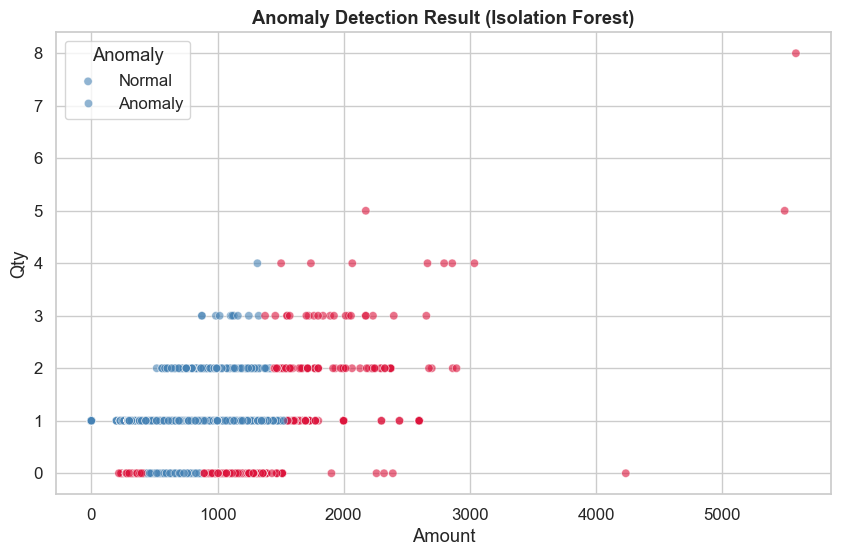


Top 10 anomali berdasarkan skor:
      Date  Amount  Qty      Category                       Status  anomaly_score
2022-05-07  2796.0    4         kurta Shipped - Returned to Seller       0.095824
2022-06-06  2664.0    4           Set                      Shipped       0.095824
2022-04-28  2175.0    3 Western Dress Shipped - Delivered to Buyer       0.095824
2022-04-06  2860.0    4 Western Dress Shipped - Delivered to Buyer       0.095824
2022-04-18  2232.0    3 Western Dress Shipped - Delivered to Buyer       0.095824
2022-04-02  2397.0    3           Set                      Shipped       0.095824
2022-05-02  3036.0    4           Set                      Shipped       0.095824
2022-04-05  5584.0    8           Set                      Shipped       0.095824
2022-06-11  2175.0    5         kurta Shipped - Delivered to Buyer       0.095824
2022-04-23  5495.0    5           Set Shipped - Delivered to Buyer       0.095824


In [25]:
# =============================================================================
# ANOMALY DETECTION (ISOLATION FOREST)
# =============================================================================

from sklearn.ensemble import IsolationForest

anomaly_features = [col for col in numeric_cols if df[col].notna().sum() > 0]

if len(anomaly_features) == 0:
    print("Tidak ada fitur numerik untuk anomaly detection.")
else:
    # Median imputation sederhana agar model bisa memproses nilai kosong
    anomaly_data = df[anomaly_features].copy()
    anomaly_data = anomaly_data.fillna(anomaly_data.median())

    iso_forest = IsolationForest(
        contamination=0.03,
        random_state=42
    )

    raw_pred = iso_forest.fit_predict(anomaly_data)
    anomaly_score = -iso_forest.decision_function(anomaly_data)

    df['anomaly_flag'] = np.where(raw_pred == -1, 1, 0)
    df['anomaly_score'] = anomaly_score

    print("Anomaly detection selesai.")
    print(f"Total data: {len(df)}")
    print(f"Jumlah anomali: {df['anomaly_flag'].sum()}")
    print(f"Persentase anomali: {df['anomaly_flag'].mean() * 100:.2f}%")

    # Visualisasi cepat menggunakan 2 fitur numerik pertama
    if len(anomaly_features) >= 2:
        x_col, y_col = anomaly_features[0], anomaly_features[1]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue='anomaly_flag',
            palette={0: 'steelblue', 1: 'crimson'},
            alpha=0.6
        )
        plt.title('Anomaly Detection Result (Isolation Forest)', fontweight='bold')
        plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
        plt.show()

    top_anomalies = (
        df[df['anomaly_flag'] == 1]
        .sort_values('anomaly_score', ascending=False)
        .head(10)
    )

    display_cols = [col for col in ['Date', 'Amount', 'Qty', 'Category', 'Status'] if col in df.columns]
    display_cols = display_cols + ['anomaly_score']

    print("\nTop 10 anomali berdasarkan skor:")
    print(top_anomalies[display_cols].to_string(index=False))

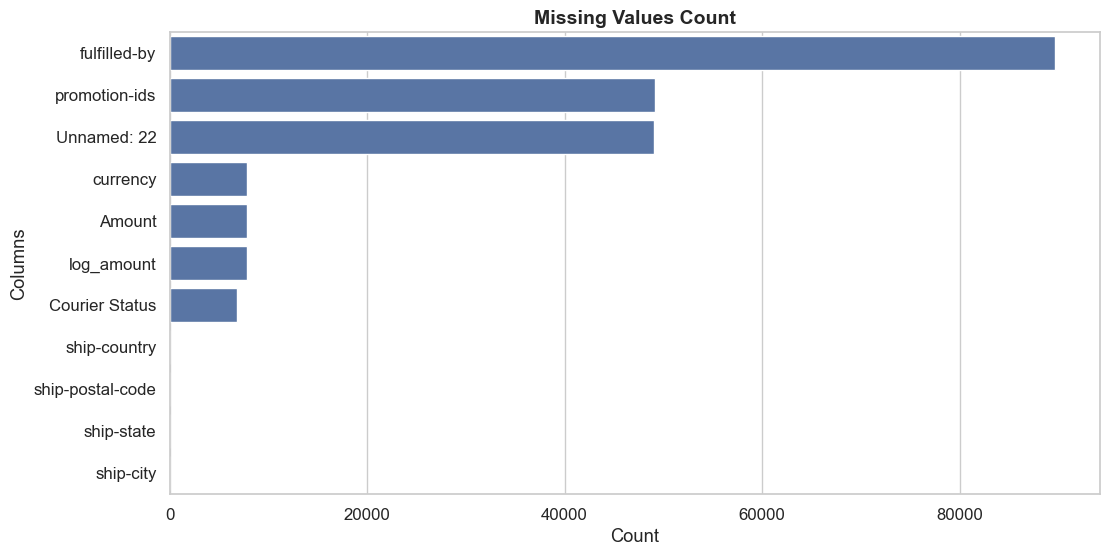

In [26]:
# =============================================================================
# MISSING VALUES VISUALIZATION
# =============================================================================

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title(
    'Missing Values Count',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Count')
plt.ylabel('Columns')

plt.show()

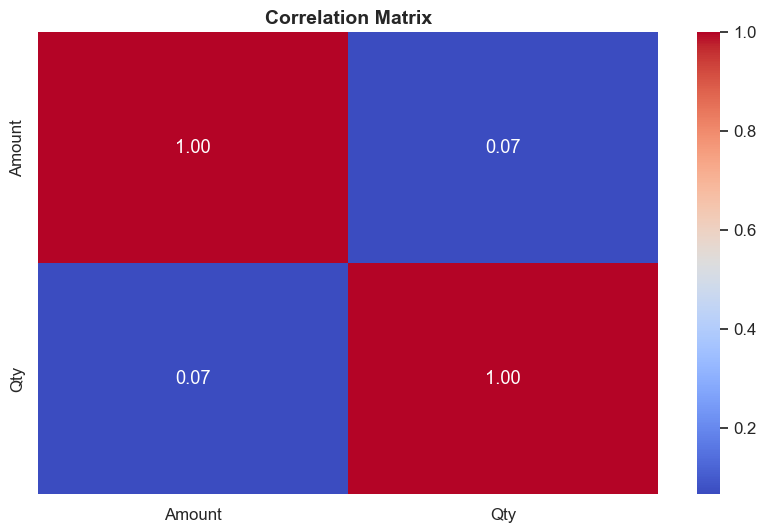

In [27]:
# =============================================================================
# CORRELATION MATRIX
# =============================================================================

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.show()

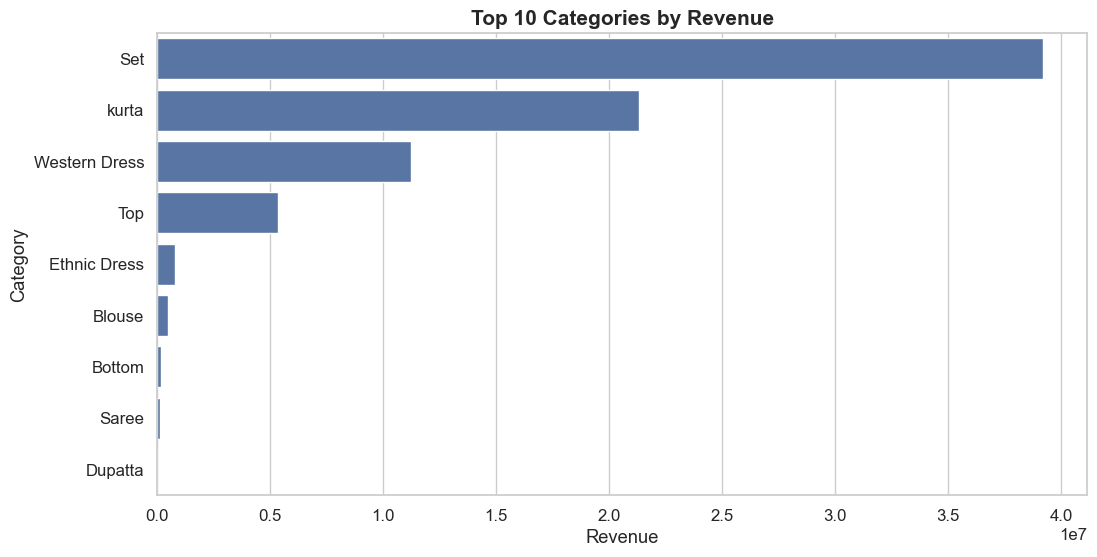

In [28]:
# =============================================================================
# TOP SELLING CATEGORIES
# =============================================================================

top_categories = (
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title(
    'Top 10 Categories by Revenue',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Revenue')

plt.show()

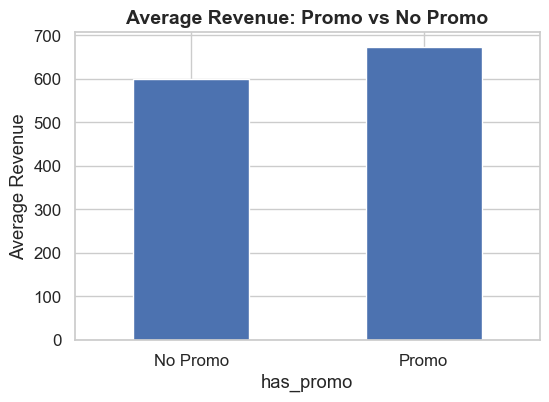

In [29]:
# =============================================================================
# PROMOTION EFFECT (robust to missing 'has_promo')
# =============================================================================

promo_col = 'has_promo'
if promo_col not in df.columns:
    if 'promotion-ids' in df.columns:
        df[promo_col] = df['promotion-ids'].notna().astype(int)
    else:
        df[promo_col] = 0  # no promotion info available

promo_sales = df.groupby(promo_col)['Amount'].mean().reindex([0,1], fill_value=0)

promo_sales.plot(kind='bar', figsize=(6,4))
plt.title('Average Revenue: Promo vs No Promo', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['No Promo', 'Promo'], rotation=0)
plt.ylabel('Average Revenue')
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [30]:
# =============================================================================
# E-COMMERCE DEMAND FORECASTING - PRODUCTION DATA CLEANING PIPELINE
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

# =============================================================================
# CONFIG
# =============================================================================

INPUT_FILE = "../amazon_sales_raw/amazon_sale_raw.csv"

CLEAN_OUTPUT = "cleaned_amazon_sales.csv"
TS_OUTPUT = "daily_demand_forecasting.csv"
STATE_OUTPUT = "daily_demand_by_state.csv"
SKU_OUTPUT = "daily_demand_by_sku.csv"

VALID_STATUS = {
    "Shipped",
    "Shipped - Delivered to Buyer",
}

TEXT_COLUMNS = [
    "Status",
    "Fulfilment",
    "Sales Channel ",
    "ship-service-level",
    "Style",
    "SKU",
    "Category",
    "Size",
    "ASIN",
    "Courier Status",
    "ship-city",
    "ship-state",
    "ship-country",
    "fulfilled-by",
]

SHIPPING_COLUMNS = [
    "ship-city",
    "ship-state",
    "ship-postal-code",
    "ship-country",
]


# =============================================================================
# HELPERS
# =============================================================================

def print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def safe_strip(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()


def remove_outliers_iqr(
    df: pd.DataFrame,
    column: str,
    multiplier: float = 1.5,
) -> pd.DataFrame:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    return df[(df[column] >= lower) & (df[column] <= upper)]


# =============================================================================
# LOAD DATA
# =============================================================================

print_section("LOAD DATA")

input_path = Path(INPUT_FILE)

if not input_path.exists():
    raise FileNotFoundError(f"Dataset not found: {input_path.resolve()}")

df = pd.read_csv(input_path)

print(f"Dataset Loaded: {input_path}")
print(f"Initial Shape: {df.shape}")


# =============================================================================
# INITIAL DATA QUALITY CHECK
# =============================================================================

print_section("INITIAL DATA QUALITY CHECK")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())


# =============================================================================
# REMOVE DUPLICATES
# =============================================================================

print_section("REMOVE DUPLICATES")

if "Order ID" in df.columns:
    before = len(df)

    df = df.drop_duplicates(subset=["Order ID"])

    after = len(df)

    print(f"Duplicates Removed Using Order ID: {before - after}")

else:
    before = len(df)

    df = df.drop_duplicates()

    after = len(df)

    print(f"Duplicates Removed: {before - after}")

print(f"Shape After Deduplication: {df.shape}")


# =============================================================================
# DROP USELESS COLUMNS
# =============================================================================

print_section("DROP UNUSED COLUMNS")

drop_cols = []

for col in df.columns:
    if "unnamed" in col.lower():
        drop_cols.append(col)

if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"Dropped Columns: {drop_cols}")

print(f"Remaining Columns: {len(df.columns)}")


# =============================================================================
# DATE CLEANING
# =============================================================================

print_section("DATE CLEANING")

if "Date" not in df.columns:
    raise KeyError("Column 'Date' not found.")

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m-%d-%y",
    errors="coerce",
)

invalid_dates = df["Date"].isnull().sum()

print(f"Invalid Dates Removed: {invalid_dates}")

df = df.dropna(subset=["Date"])


# =============================================================================
# NUMERIC CLEANING
# =============================================================================

print_section("NUMERIC CLEANING")

numeric_cols = ["Amount", "Qty"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nNumeric Null Counts:")
print(df[numeric_cols].isnull().sum())


# =============================================================================
# STATUS FILTERING
# =============================================================================

print_section("STATUS FILTERING")

if "Status" in df.columns:
    print("\nStatus Distribution Before:")
    print(df["Status"].value_counts(dropna=False))

    before = len(df)

    df = df[df["Status"].isin(VALID_STATUS)]

    after = len(df)

    print(f"\nRows Removed By Status Filter: {before - after}")

    print("\nStatus Distribution After:")
    print(df["Status"].value_counts(dropna=False))


# =============================================================================
# REMOVE INVALID VALUES
# =============================================================================

print_section("REMOVE INVALID VALUES")

if "Qty" in df.columns:
    before = len(df)

    df = df[df["Qty"] > 0]

    print(f"Removed Invalid Qty Rows: {before - len(df)}")

if "Amount" in df.columns:
    before = len(df)

    df = df.dropna(subset=["Amount"])
    df = df[df["Amount"] > 0]

    print(f"Removed Invalid Amount Rows: {before - len(df)}")


# =============================================================================
# REMOVE OUTLIERS
# =============================================================================

print_section("REMOVE OUTLIERS")

if "Amount" in df.columns:
    before = len(df)

    df = remove_outliers_iqr(df, "Amount")

    after = len(df)

    print(f"Outliers Removed: {before - after}")


# =============================================================================
# SHIPPING DATA CLEANING
# =============================================================================

print_section("SHIPPING DATA CLEANING")

existing_shipping_cols = [
    col for col in SHIPPING_COLUMNS
    if col in df.columns
]

if existing_shipping_cols:
    before = len(df)

    df = df.dropna(subset=existing_shipping_cols)

    after = len(df)

    print(f"Rows Removed Due Missing Shipping Data: {before - after}")


# =============================================================================
# PROMOTION CLEANING
# =============================================================================

print_section("PROMOTION CLEANING")

if "promotion-ids" in df.columns:
    df["has_promo"] = (
        df["promotion-ids"]
        .notnull()
        .astype(int)
)

    df["promotion-ids"] = (
        df["promotion-ids"]
        .fillna("No Promotion")
)

else:
    df["has_promo"] = 0
    df["promotion-ids"] = "No Promotion"


# =============================================================================
# FULFILLMENT CLEANING
# =============================================================================

print_section("FULFILLMENT CLEANING")

if "fulfilled-by" in df.columns:
    df["fulfilled-by"] = (
        df["fulfilled-by"]
        .fillna("Merchant")
)

if "Courier Status" in df.columns:
    df["Courier Status"] = (
        df["Courier Status"]
        .fillna("Unknown")
)


# =============================================================================
# CURRENCY CLEANING
# =============================================================================

print_section("CURRENCY CLEANING")

if "currency" in df.columns:
    print("\nCurrency Distribution:")
    print(df["currency"].value_counts(dropna=False))

    df["currency"] = df["currency"].fillna("INR")

    if df["currency"].nunique() > 1:
        print("\n[WARNING] Multiple currencies detected.")

        before = len(df)

        df = df[df["currency"] == "INR"]

        after = len(df)

        print(f"Removed Non-INR Rows: {before - after}")


# =============================================================================
# TEXT CLEANING
# =============================================================================

print_section("TEXT CLEANING")

for col in TEXT_COLUMNS:
    if col in df.columns:
        df[col] = safe_strip(df[col])

print("Text Cleaning Completed.")


# =============================================================================
# DATA TYPE FIXING
# =============================================================================

print_section("DATA TYPE FIXING")

if "Qty" in df.columns:
    df["Qty"] = df["Qty"].astype(int)

if "ship-postal-code" in df.columns:
    df["ship-postal-code"] = (
        df["ship-postal-code"]
        .astype(str)
        .str.strip()
)

if "B2B" in df.columns:
    df["B2B"] = (
        df["B2B"]
        .astype(bool)
        .astype(int)
)

print(df.dtypes)


# =============================================================================
# SORTING
# =============================================================================

print_section("SORTING")

df = df.sort_values(by="Date")

df = df.reset_index(drop=True)

print("Data Sorted By Date.")


# =============================================================================
# FINAL DATA QUALITY CHECK
# =============================================================================

print_section("FINAL CLEANED DATA OVERVIEW")

print(f"\nFinal Shape: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDescribe:")
print(df.describe(include="all"))


# =============================================================================
# DEMAND AGGREGATION (CATEGORY, STATE, SKU)
# =============================================================================

print_section("DEMAND AGGREGATION")

if "Qty" not in df.columns:
    raise KeyError("Column 'Qty' not found for demand aggregation.")

required_cols = {"Date", "Category"}
if not required_cols.issubset(df.columns):
    raise KeyError("Columns 'Date' and 'Category' are required for demand per category.")

demand_category = (
    df.groupby(["Date", "Category"])["Qty"]
    .sum()
    .reset_index()
)

demand_category = demand_category.rename(
    columns={"Qty": "Daily_Demand"}
)

print(demand_category.head())

demand_state = None
if "ship-state" in df.columns:
    demand_state = (
        df.groupby(["Date", "ship-state"])["Qty"]
        .sum()
        .reset_index()
)
    demand_state = demand_state.rename(
        columns={"Qty": "Daily_Demand"}
)

demand_sku = None
if "SKU" in df.columns:
    demand_sku = (
        df.groupby(["Date", "SKU"])["Qty"]
        .sum()
        .reset_index()
)
    demand_sku = demand_sku.rename(
        columns={"Qty": "Daily_Demand"}
)

# =============================================================================
# TIME FEATURES (PRIMARY: CATEGORY DEMAND)
# =============================================================================

print_section("TIME FEATURE ENGINEERING")

category_ts = demand_category.copy()

category_ts["day"] = category_ts["Date"].dt.day
category_ts["month"] = category_ts["Date"].dt.month
category_ts["year"] = category_ts["Date"].dt.year
category_ts["weekday"] = category_ts["Date"].dt.weekday
category_ts["weekofyear"] = (
    category_ts["Date"]
    .dt
    .isocalendar()
    .week
    .astype(int)
)
category_ts["quarter"] = category_ts["Date"].dt.quarter
category_ts["is_weekend"] = (
    category_ts["weekday"] >= 5
).astype(int)
category_ts["month_start"] = (
    category_ts["Date"]
    .dt
    .is_month_start
    .astype(int)
)
category_ts["month_end"] = (
    category_ts["Date"]
    .dt
    .is_month_end
    .astype(int)
)

print("Time Features Created.")


# =============================================================================
# LAG FEATURES (CATEGORY DEMAND)
# =============================================================================

print_section("LAG FEATURE ENGINEERING")

category_ts = category_ts.sort_values(["Category", "Date"])

category_ts["lag_1"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(1)
)
category_ts["lag_7"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(7)
)
category_ts["lag_14"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(14)
)
category_ts["lag_30"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(30)
)

print("Lag Features Created.")


# =============================================================================
# ROLLING FEATURES (CATEGORY DEMAND)
# =============================================================================

print_section("ROLLING FEATURE ENGINEERING")

category_ts["rolling_mean_7"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)
category_ts["rolling_std_7"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(1)
    .rolling(window=7)
    .std()
)
category_ts["rolling_mean_30"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(1)
    .rolling(window=30)
    .mean()
)
category_ts["rolling_std_30"] = (
    category_ts.groupby("Category")["Daily_Demand"]
    .shift(1)
    .rolling(window=30)
    .std()
)

print("Rolling Features Created.")


# =============================================================================
# DROP NULLS AFTER FEATURE ENGINEERING
# =============================================================================

print_section("REMOVE NULLS AFTER FEATURE ENGINEERING")

before = len(category_ts)

category_ts = category_ts.dropna()

after = len(category_ts)

print(f"Rows Removed: {before - after}")

print(f"Final Time Series Shape: {category_ts.shape}")


# =============================================================================
# FINAL TIME SERIES CHECK
# =============================================================================

print_section("FINAL TIME SERIES DATASET")

print(category_ts.head())

print("\nDataset Info:")
print(category_ts.info())


# =============================================================================
# SAVE OUTPUT
# =============================================================================

print_section("SAVE OUTPUT")

df.to_csv(CLEAN_OUTPUT, index=False)
category_ts.to_csv(TS_OUTPUT, index=False)

if demand_state is not None:
    demand_state.to_csv(STATE_OUTPUT, index=False)
if demand_sku is not None:
    demand_sku.to_csv(SKU_OUTPUT, index=False)

print(f"Saved Clean Dataset → {CLEAN_OUTPUT}")
print(f"Saved Demand (Category) Dataset → {TS_OUTPUT}")
if demand_state is not None:
    print(f"Saved Demand (State) Dataset → {STATE_OUTPUT}")
if demand_sku is not None:
    print(f"Saved Demand (SKU) Dataset → {SKU_OUTPUT}")


# =============================================================================
# DONE
# =============================================================================

print_section("DATA CLEANING COMPLETED SUCCESSFULLY")


LOAD DATA
Dataset Loaded: ..\amazon_sales_raw\amazon_sale_raw.csv
Initial Shape: (128975, 24)

INITIAL DATA QUALITY CHECK

Missing Values:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

Duplicate Rows:
0

Columns:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier